<a href="https://colab.research.google.com/github/AbenyT/10academy.org/blob/main/AASHTO_1993_MD_(capping_layer_(with_mr_option)_(CGM)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [3]:
def get_ZR(reliability):
    """
    Convert reliability percentage to standard normal deviate (ZR)
    """
    zr_map = {
        50: 0.000, 60: -0.253, 70: -0.524, 75: -0.674, 80: -0.841,
        85: -1.037, 90: -1.282, 91: -1.340, 92: -1.405, 93: -1.476,
        94: -1.555, 95: -1.645, 96: -1.751, 97: -1.881, 98: -2.045,
        99: -2.327, 99.9: -3.090, 99.99: -3.750
    }
    return zr_map.get(reliability, -1.645)


def get_MR(cbr, custom_mr=None):
    """
    Calculate Resilient Modulus (MR) from CBR
    MR = 1500*CBR if CBR < 5%, otherwise use custom value

    Calculate Resilient Modulus based on CBR
    If CBR > 5%: MR = 145 * 17.6 * CBR^0.64
    If CBR ≤ 5%: MR = 1500 * CBR
    """
    if cbr > 5:
        MR = 145 * 17.6 * (cbr ** 0.64)
    elif custom_mr is not None and cbr >= 10:
        MR = custom_mr
    else:
        MR = 1500 * cbr
    return MR


print("✓ Helper functions defined!")


✓ Helper functions defined!


In [4]:
def aashto_equation(SN, W18, MR, ZR, So, DPSI):
    """
    AASHTO 1993 Flexible Pavement Design Equation
    log10(W18) = ZR*So + 9.36*log10(SN+1) - 0.20 +
                 [log10(ΔPSI/(4.2-1.5)) / (0.40 + 1094/(SN+1)^5.19)] +
                 2.32*log10(MR) - 8.07
    """
    term1 = ZR * So
    term2 = 9.36 * np.log10(SN + 1)
    term3 = -0.20

    numerator = np.log10(DPSI / (4.2 - 1.5))
    denominator = 0.40 + (1094 / np.power(SN + 1, 5.19))
    term4 = numerator / denominator

    term5 = 2.32 * np.log10(MR)
    term6 = -8.07

    left_side = term1 + term2 + term3 + term4 + term5 + term6
    right_side = np.log10(W18 * 1e6)

    return left_side - right_side

def solve_for_SN(W18, MR, ZR, So, DPSI):
    """
    Solve for required Structural Number (SN) using numerical method
    """
    SN_initial = 5.0
    SN_solution = fsolve(aashto_equation, SN_initial,
                         args=(W18, MR, ZR, So, DPSI))
    return SN_solution[0]

print("✓ AASHTO equation functions defined!")

✓ AASHTO equation functions defined!


In [5]:
def get_user_input(prompt, default_value, value_type=float):
    """
    Get user input with validation and default value
    """
    while True:
        try:
            user_input = input(f"{prompt} [default: {default_value}]: ").strip()
            if user_input == "":
                return default_value
            return value_type(user_input)
        except ValueError:
            print(f"  ⚠️  Invalid input! Please enter a valid number.")

print("✓ Input function defined!")

✓ Input function defined!


In [6]:
# Interactive input for design parameters
print("\n" + "="*70)
print("  🛣️  AASHTO 1993 FLEXIBLE PAVEMENT DESIGN CALCULATOR")
print("="*70)
print("\nPlease enter the following design parameters:")
print("(Press Enter to use default values)\n")

# ========== DESIGN CONDITIONS ==========
print("📋 DESIGN CONDITIONS:")
reliability = get_user_input("  • Reliability (%)", 95)
so = get_user_input("  • Standard Deviation (So)", 0.45)
w18 = get_user_input("  • Design ESAL (×10⁶)", 115.6)
dpsi = get_user_input("  • ΔPSI (Serviceability Loss)", 2.20)

# ========== ASK ABOUT CAPPING LAYER ==========
print("\n🔧 PAVEMENT STRUCTURE OPTIONS:")
use_capping = input("  • Do you need a Capping Layer? (yes/no) [default: no]: ").strip().lower()
use_capping_layer = use_capping in ['yes', 'y', 'yeah', 'yep']

if use_capping_layer:
    print("  ✓ Capping layer will be included in the design")
else:
    print("  ✓ Design will proceed without capping layer")

# ========== ASK ABOUT MR CALCULATION METHOD ==========
print("\n🔬 RESILIENT MODULUS (MR) CALCULATION METHOD:")
print("   Option 1: Calculate MR from CBR values (MR = 145×17.6×CBR^0.64 if CBR>5%, else MR = 1500×CBR)")
print("   Option 2: Enter MR values directly (manual input)")

mr_method = input("\n  • Choose method (1 or 2) [default: 1]: ").strip()
use_cbr_for_mr = mr_method != '2'

if use_cbr_for_mr:
    print("  ✓ MR will be calculated from CBR values")
else:
    print("  ✓ MR values will be entered manually")

# ========== CBR OR MR INPUT BASED ON SELECTION ==========
if use_cbr_for_mr:
    # INPUT CBR VALUES
    print("\n🔬 CBR VALUES FOR EACH LAYER:")
    print("   (MR will be calculated as: MR = 145×17.6×CBR^0.64 if CBR>5%, else MR = 1500×CBR)")

    cbr_subgrade = get_user_input("  • CBR of Subgrade (%)", 5.0)

    if use_capping_layer:
        cbr_capping = get_user_input("  • CBR of Capping Layer (%)", 15.0)

    cbr_subbase = get_user_input("  • CBR of Subbase (%)", 30.0)
    cbr_base = get_user_input("  • CBR of Base (%)", 80.0)
    cbr_surface = get_user_input("  • CBR of Surface/DBM (%)", 100.0)

    # Calculate MR from CBR
    def calculate_MR(cbr, layer_name=""):
        """
        Calculate Resilient Modulus based on CBR
        If CBR > 5%: MR = 145 * 17.6 * CBR^0.64
        If CBR ≤ 5%: MR = 1500 * CBR
        """
        if cbr > 5:
            MR = 145 * 17.6 * (cbr ** 0.64)
            formula_used = f"145 × 17.6 × {cbr}^0.64"
        else:
            MR = 1500 * cbr
            formula_used = f"1500 × {cbr}"

        if layer_name:
            print(f"  • {layer_name}: MR = {formula_used} = {MR:,.0f} psi")

        return MR

    # Calculate ZR
    ZR = get_ZR(reliability)

    print("\n" + "="*70)
    print("  📊 CALCULATED DESIGN PARAMETERS")
    print("="*70)
    print(f"\n  Standard Normal Deviate (ZR): {ZR:.3f}")
    print("\n  Resilient Modulus (MR) Calculations:")

    # Calculate MR for each layer
    MR_subgrade = calculate_MR(cbr_subgrade, f"Subgrade (CBR {cbr_subgrade}%)")

    if use_capping_layer:
        MR_capping = calculate_MR(cbr_capping, f"Capping Layer (CBR {cbr_capping}%)")

    MR_subbase = calculate_MR(cbr_subbase, f"Subbase (CBR {cbr_subbase}%)")
    MR_base = calculate_MR(cbr_base, f"Base (CBR {cbr_base}%)")
    MR_surface = calculate_MR(cbr_surface, f"Surface/DBM (CBR {cbr_surface}%)")

else:
    # INPUT MR VALUES DIRECTLY
    print("\n🔢 RESILIENT MODULUS (MR) VALUES (psi):")
    print("   Enter MR values directly for each layer")

    MR_subgrade = get_user_input("  • MR of Subgrade (psi)", 7500)

    if use_capping_layer:
        MR_capping = get_user_input("  • MR of Capping Layer (psi)", 15000)

    MR_subbase = get_user_input("  • MR of Subbase (psi)", 15000)
    MR_base = get_user_input("  • MR of Base (psi)", 30000)
    MR_surface = get_user_input("  • MR of Surface/DBM (psi)", 400000)

    # For display purposes, calculate equivalent CBR (reverse calculation)
    def calculate_cbr_from_mr(mr):
        """Estimate CBR from MR (approximate reverse calculation)"""
        if mr <= 7500:
            return mr / 1500
        else:
            # Solve: MR = 145 * 17.6 * CBR^0.64
            # CBR = (MR / (145 * 17.6))^(1/0.64)
            return (mr / (145 * 17.6)) ** (1/0.64)

    cbr_subgrade = calculate_cbr_from_mr(MR_subgrade)
    if use_capping_layer:
        cbr_capping = calculate_cbr_from_mr(MR_capping)
    cbr_subbase = calculate_cbr_from_mr(MR_subbase)
    cbr_base = calculate_cbr_from_mr(MR_base)
    cbr_surface = calculate_cbr_from_mr(MR_surface)

    # Calculate ZR
    ZR = get_ZR(reliability)

    print("\n" + "="*70)
    print("  📊 DESIGN PARAMETERS SUMMARY")
    print("="*70)
    print(f"\n  Standard Normal Deviate (ZR): {ZR:.3f}")
    print("\n  Resilient Modulus (MR) Values:")
    print(f"  • Subgrade: {MR_subgrade:,.0f} psi (approx. CBR {cbr_subgrade:.1f}%)")
    if use_capping_layer:
        print(f"  • Capping Layer: {MR_capping:,.0f} psi (approx. CBR {cbr_capping:.1f}%)")
    print(f"  • Subbase: {MR_subbase:,.0f} psi (approx. CBR {cbr_subbase:.1f}%)")
    print(f"  • Base: {MR_base:,.0f} psi (approx. CBR {cbr_base:.1f}%)")
    print(f"  • Surface/DBM: {MR_surface:,.0f} psi (approx. CBR {cbr_surface:.1f}%)")

print("\n" + "="*70)

# ========== LAYER COEFFICIENTS ==========
print("\n🔢 LAYER COEFFICIENTS:")
a1 = get_user_input("  • a1 (AC Course coefficient)", 0.44)
a2 = get_user_input("  • a2 (DBM Course coefficient)", 0.34)
a3 = get_user_input("  • a3 (Base Course coefficient)", 0.14)
a4 = get_user_input("  • a4 (Subbase coefficient)", 0.11)

if use_capping_layer:
    a5 = get_user_input("  • a5 (Capping Layer coefficient)", 0.08)

# ========== DRAINAGE COEFFICIENTS ==========
print("\n💧 DRAINAGE COEFFICIENTS:")
m2 = get_user_input("  • m2 (DBM drainage coefficient)", 1.0)
m3 = get_user_input("  • m3 (Base drainage coefficient)", 1.0)
m4 = get_user_input("  • m4 (Subbase drainage coefficient)", 1.0)

if use_capping_layer:
    m5 = get_user_input("  • m5 (Capping Layer drainage coefficient)", 1.0)

print("\n✅ All design parameters received!")

# Calculate required SN for each layer
print("\n⏳ Calculating required Structural Numbers...\n")

SN_required = solve_for_SN(w18, MR_subgrade, ZR, so, dpsi)
SN1_required = solve_for_SN(w18, MR_surface, ZR, so, dpsi)
SN2_required = solve_for_SN(w18, MR_base, ZR, so, dpsi)
SN3_required = solve_for_SN(w18, MR_subbase, ZR, so, dpsi)

if use_capping_layer:
    SN4_required = solve_for_SN(w18, MR_capping, ZR, so, dpsi)

print(f"✓ Total Required SN (on Subgrade): {SN_required:.3f}")
print(f"✓ Required SN1 (for Surface): {SN1_required:.3f}")
print(f"✓ Required SN2 (for Base): {SN2_required:.3f}")
print(f"✓ Required SN3 (for Subbase): {SN3_required:.3f}")

if use_capping_layer:
    print(f"✓ Required SN4 (for Capping): {SN4_required:.3f}")

print("\n" + "="*70)


  🛣️  AASHTO 1993 FLEXIBLE PAVEMENT DESIGN CALCULATOR

Please enter the following design parameters:
(Press Enter to use default values)

📋 DESIGN CONDITIONS:
  • Reliability (%) [default: 95]: 95
  • Standard Deviation (So) [default: 0.45]: 0.45
  • Design ESAL (×10⁶) [default: 115.6]: 115.6
  • ΔPSI (Serviceability Loss) [default: 2.2]: 2.2

🔧 PAVEMENT STRUCTURE OPTIONS:
  • Do you need a Capping Layer? (yes/no) [default: no]: no
  ✓ Design will proceed without capping layer

🔬 RESILIENT MODULUS (MR) CALCULATION METHOD:
   Option 1: Calculate MR from CBR values (MR = 145×17.6×CBR^0.64 if CBR>5%, else MR = 1500×CBR)
   Option 2: Enter MR values directly (manual input)

  • Choose method (1 or 2) [default: 1]: 2
  ✓ MR values will be entered manually

🔢 RESILIENT MODULUS (MR) VALUES (psi):
   Enter MR values directly for each layer
  • MR of Subgrade (psi) [default: 7500]: 7500
  • MR of Subbase (psi) [default: 15000]: 87022.8
  • MR of Base (psi) [default: 30000]: 560000
  • MR of Su

In [9]:
print("  🏗️  LAYER-BY-LAYER PAVEMENT DESIGN")
print("="*70)
print("\nNow you will design each layer thickness step by step.\n")

# Initialize cumulative SN
cumulative_SN = 0.0
layer_data = []

# ========== LAYER 1: AC COURSE ==========
print("─" * 70)
print("LAYER 1: AC COURSE (Asphalt Concrete)")
print("─" * 70)

# Calculate minimum D1
D1_min_inches = SN1_required / a1
D1_min_cm = D1_min_inches * 2.54
D1_min_mm = D1_min_cm * 10

print(f"  Required SN1: {SN1_required:.3f}")
print(f"  Layer Coefficient (a1): {a1}")
print(f"  Minimum D1 required: {D1_min_mm:.1f} mm ({D1_min_cm:.2f} cm, {D1_min_inches:.2f} inches)")

D1_mm = get_user_input(f"\n  ➤ Enter AC Course thickness (mm)", D1_min_mm)
D1_inches = D1_mm / 25.4
SN1_actual = D1_inches * a1
cumulative_SN += SN1_actual

print(f"\n  ✓ Selected D1: {D1_mm:.1f} mm")
print(f"  ✓ SN1 contribution: {SN1_actual:.3f}")
print(f"  ✓ Cumulative SN: {cumulative_SN:.3f}")

layer_data.append({
    'Layer': 'AC Course',
    'Thickness_mm': D1_mm,
    'Thickness_inches': D1_inches,
    'Coefficient': a1,
    'Drainage': 1.0,
    'SN_contribution': SN1_actual,
    'Cumulative_SN': cumulative_SN
})

# ========== LAYER 2: DBM COURSE ==========
print("\n" + "─" * 70)
print("LAYER 2: DBM COURSE (Dense Bituminous Macadam)")
print("─" * 70)

remaining_SN = SN2_required - SN1_actual
D2_min_inches = max(0, remaining_SN / (a2 * m2))
D2_min_cm = D2_min_inches * 2.54
D2_min_mm = D2_min_cm * 10

print(f"  Required SN2: {SN2_required:.3f}")
print(f"  Already provided by Layer 1: {SN1_actual:.3f}")
print(f"  Remaining SN needed: {remaining_SN:.3f}")
print(f"  Layer Coefficient (a2): {a2}")
print(f"  Drainage Coefficient (m2): {m2}")
print(f"  Minimum D2 required: {D2_min_mm:.1f} mm ({D2_min_cm:.2f} cm, {D2_min_inches:.2f} inches)")

D2_mm = get_user_input(f"\n  ➤ Enter DBM Course thickness (mm)", max(D2_min_mm, 0))
D2_inches = D2_mm / 25.4
SN2_actual = D2_inches * a2 * m2
cumulative_SN += SN2_actual

print(f"\n  ✓ Selected D2: {D2_mm:.1f} mm")
print(f"  ✓ SN2 contribution: {SN2_actual:.3f}")
print(f"  ✓ Cumulative SN: {cumulative_SN:.3f}")

layer_data.append({
    'Layer': 'DBM Course',
    'Thickness_mm': D2_mm,
    'Thickness_inches': D2_inches,
    'Coefficient': a2,
    'Drainage': m2,
    'SN_contribution': SN2_actual,
    'Cumulative_SN': cumulative_SN
})

# ========== LAYER 3: BASE COURSE ==========
print("\n" + "─" * 70)
print("LAYER 3: CRUSHED AGGREGATE BASE")
print("─" * 70)

remaining_SN = SN3_required - cumulative_SN
D3_min_inches = max(0, remaining_SN / (a3 * m3))
D3_min_cm = D3_min_inches * 2.54
D3_min_mm = D3_min_cm * 10

print(f"  Required SN3: {SN3_required:.3f}")
print(f"  Already provided by Layers 1-2: {cumulative_SN:.3f}")
print(f"  Remaining SN needed: {remaining_SN:.3f}")
print(f"  Layer Coefficient (a3): {a3}")
print(f"  Drainage Coefficient (m3): {m3}")
print(f"  Minimum D3 required: {D3_min_mm:.1f} mm ({D3_min_cm:.2f} cm, {D3_min_inches:.2f} inches)")

D3_mm = get_user_input(f"\n  ➤ Enter Base Course thickness (mm)", max(D3_min_mm, 0))
D3_inches = D3_mm / 25.4
SN3_actual = D3_inches * a3 * m3
cumulative_SN += SN3_actual

print(f"\n  ✓ Selected D3: {D3_mm:.1f} mm")
print(f"  ✓ SN3 contribution: {SN3_actual:.3f}")
print(f"  ✓ Cumulative SN: {cumulative_SN:.3f}")

layer_data.append({
    'Layer': 'Base Course',
    'Thickness_mm': D3_mm,
    'Thickness_inches': D3_inches,
    'Coefficient': a3,
    'Drainage': m3,
    'SN_contribution': SN3_actual,
    'Cumulative_SN': cumulative_SN
})

# ========== LAYER 4: SUBBASE ==========
print("\n" + "─" * 70)
print("LAYER 4: AGGREGATE SUBBASE")
print("─" * 70)

if use_capping_layer:
    remaining_SN = SN4_required - cumulative_SN
else:
    remaining_SN = SN_required - cumulative_SN

D4_min_inches = max(0, remaining_SN / (a4 * m4))
D4_min_cm = D4_min_inches * 2.54
D4_min_mm = D4_min_cm * 10

if use_capping_layer:
    print(f"  Required SN4 (for Capping): {SN4_required:.3f}")
else:
    print(f"  Total Required SN: {SN_required:.3f}")

print(f"  Already provided by Layers 1-3: {cumulative_SN:.3f}")
print(f"  Remaining SN needed: {remaining_SN:.3f}")
print(f"  Layer Coefficient (a4): {a4}")
print(f"  Drainage Coefficient (m4): {m4}")
print(f"  Minimum D4 required: {D4_min_mm:.1f} mm ({D4_min_cm:.2f} cm, {D4_min_inches:.2f} inches)")

D4_mm = get_user_input(f"\n  ➤ Enter Subbase thickness (mm)", max(D4_min_mm, 0))
D4_inches = D4_mm / 25.4
SN4_actual = D4_inches * a4 * m4
cumulative_SN += SN4_actual

print(f"\n  ✓ Selected D4: {D4_mm:.1f} mm")
print(f"  ✓ SN4 contribution: {SN4_actual:.3f}")
print(f"  ✓ Cumulative SN: {cumulative_SN:.3f}")

layer_data.append({
    'Layer': 'Subbase',
    'Thickness_mm': D4_mm,
    'Thickness_inches': D4_inches,
    'Coefficient': a4,
    'Drainage': m4,
    'SN_contribution': SN4_actual,
    'Cumulative_SN': cumulative_SN
})

# ========== LAYER 5: CAPPING LAYER (OPTIONAL) ==========
if use_capping_layer:
    print("\n" + "─" * 70)
    print("LAYER 5: CAPPING LAYER")
    print("─" * 70)

    remaining_SN = SN_required - cumulative_SN
    D5_min_inches = max(0, remaining_SN / (a5 * m5))
    D5_min_cm = D5_min_inches * 2.54
    D5_min_mm = D5_min_cm * 10

    print(f"  Total Required SN: {SN_required:.3f}")
    print(f"  Already provided by Layers 1-4: {cumulative_SN:.3f}")
    print(f"  Remaining SN needed: {remaining_SN:.3f}")
    print(f"  Layer Coefficient (a5): {a5}")
    print(f"  Drainage Coefficient (m5): {m5}")
    print(f"  Minimum D5 required: {D5_min_mm:.1f} mm ({D5_min_cm:.2f} cm, {D5_min_inches:.2f} inches)")

    D5_mm = get_user_input(f"\n  ➤ Enter Capping Layer thickness (mm)", max(D5_min_mm, 0))
    D5_inches = D5_mm / 25.4
    SN5_actual = D5_inches * a5 * m5
    cumulative_SN += SN5_actual

    print(f"\n  ✓ Selected D5: {D5_mm:.1f} mm")
    print(f"  ✓ SN5 contribution: {SN5_actual:.3f}")
    print(f"  ✓ Final Total SN: {cumulative_SN:.3f}")

    layer_data.append({
        'Layer': 'Capping Layer',
        'Thickness_mm': D5_mm,
        'Thickness_inches': D5_inches,
        'Coefficient': a5,
        'Drainage': m5,
        'SN_contribution': SN5_actual,
        'Cumulative_SN': cumulative_SN
    })

print("\n" + "="*70)

  🏗️  LAYER-BY-LAYER PAVEMENT DESIGN

Now you will design each layer thickness step by step.

──────────────────────────────────────────────────────────────────────
LAYER 1: AC COURSE (Asphalt Concrete)
──────────────────────────────────────────────────────────────────────
  Required SN1: 1.735
  Layer Coefficient (a1): 0.44
  Minimum D1 required: 100.2 mm (10.02 cm, 3.94 inches)

  ➤ Enter AC Course thickness (mm) [default: 100.18110923999389]: 100

  ✓ Selected D1: 100.0 mm
  ✓ SN1 contribution: 1.732
  ✓ Cumulative SN: 1.732

──────────────────────────────────────────────────────────────────────
LAYER 2: DBM COURSE (Dense Bituminous Macadam)
──────────────────────────────────────────────────────────────────────
  Required SN2: 1.514
  Already provided by Layer 1: 1.732
  Remaining SN needed: -0.219
  Layer Coefficient (a2): 0.34
  Drainage Coefficient (m2): 1.0
  Minimum D2 required: 0.0 mm (0.00 cm, 0.00 inches)

  ➤ Enter DBM Course thickness (mm) [default: 0.0]: 100

  ✓ Selected

In [10]:
print("  📊 FINAL DESIGN RESULTS")
print("="*70)

# Check adequacy
is_adequate = cumulative_SN >= SN_required

print(f"\n  Required Total SN: {SN_required:.3f}")
print(f"  Actual Total SN: {cumulative_SN:.3f}")
print(f"  Difference: {cumulative_SN - SN_required:+.3f}")

if is_adequate:
    print(f"\n  ✅ DESIGN IS ADEQUATE!")
    print(f"  Total SN ({cumulative_SN:.3f}) ≥ Required SN ({SN_required:.3f})")
else:
    print(f"\n  ❌ DESIGN IS NOT ADEQUATE!")
    print(f"  Total SN ({cumulative_SN:.3f}) < Required SN ({SN_required:.3f})")
    print(f"  Additional SN needed: {SN_required - cumulative_SN:.3f}")

print("\n" + "="*70)
print("  📋 LAYER SUMMARY")
print("="*70)

# Create DataFrame
df_layers = pd.DataFrame(layer_data)
df_layers['Thickness_cm'] = df_layers['Thickness_mm'] / 10

# Display table
print("\n")
print(df_layers[['Layer', 'Thickness_mm', 'Thickness_cm', 'Coefficient',
                  'SN_contribution', 'Cumulative_SN']].to_string(index=False))

print("\n" + "="*70)
print("  📈 TOTAL PAVEMENT THICKNESS")
print("="*70)

# Calculate total thickness
total_thickness_mm = sum([layer['Thickness_mm'] for layer in layer_data])
total_thickness_cm = total_thickness_mm / 10
total_thickness_inches = total_thickness_mm / 25.4

print(f"\n  Total Pavement Thickness: {total_thickness_mm:.1f} mm ({total_thickness_cm:.1f} cm, {total_thickness_inches:.2f} inches)")
print(f"  Number of Layers: {len(layer_data)}")

if use_capping_layer:
    print(f"  Design includes Capping Layer ✓")
else:
    print(f"  Design without Capping Layer")

print("\n" + "="*70)

  📊 FINAL DESIGN RESULTS

  Required Total SN: 6.688
  Actual Total SN: 6.728
  Difference: +0.041

  ✅ DESIGN IS ADEQUATE!
  Total SN (6.728) ≥ Required SN (6.688)

  📋 LAYER SUMMARY


      Layer  Thickness_mm  Thickness_cm  Coefficient  SN_contribution  Cumulative_SN
  AC Course         100.0          10.0         0.44         1.732283       1.732283
 DBM Course         100.0          10.0         0.34         1.338583       3.070866
Base Course         200.0          20.0         0.14         1.102362       4.173228
    Subbase         590.0          59.0         0.11         2.555118       6.728346

  📈 TOTAL PAVEMENT THICKNESS

  Total Pavement Thickness: 990.0 mm (99.0 cm, 38.98 inches)
  Number of Layers: 4
  Design without Capping Layer



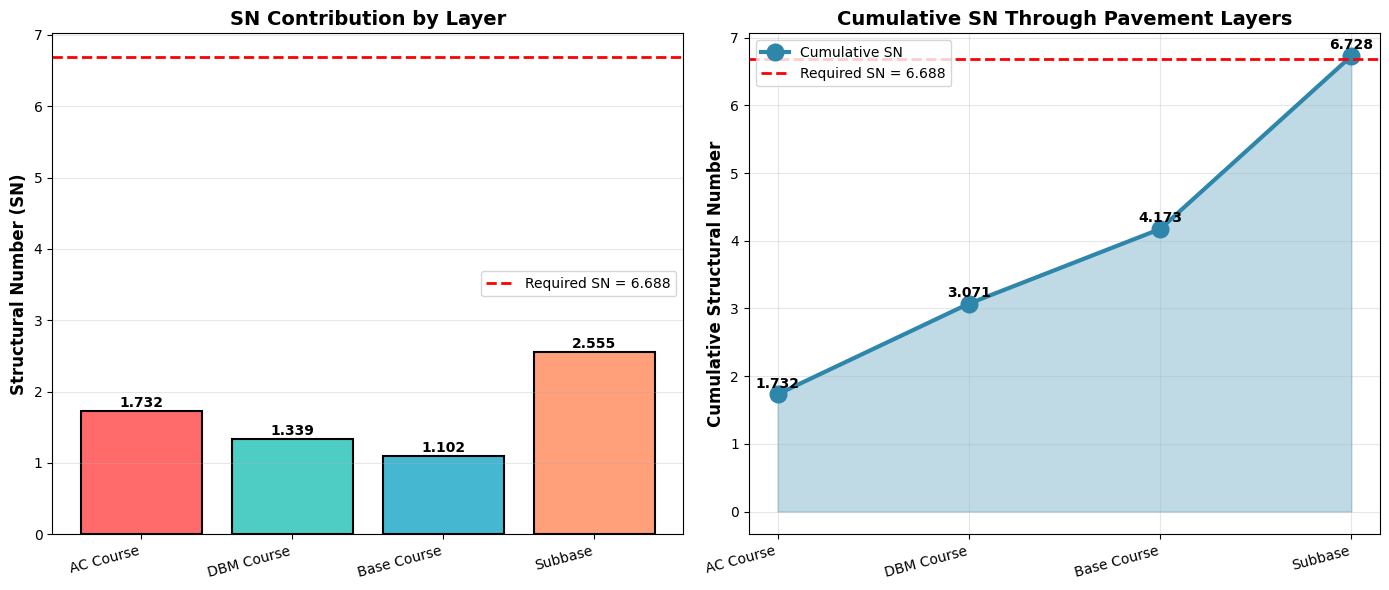


✅ Visualization complete!


In [ ]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Extract layer names and values
layers = [layer['Layer'] for layer in layer_data]
sn_values = [layer['SN_contribution'] for layer in layer_data]
cumulative_values = [layer['Cumulative_SN'] for layer in layer_data]

# Colors for layers
if use_capping_layer:
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#96CEB4']
else:
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Plot 1: SN Contributions
axes[0].bar(range(len(layers)), sn_values, color=colors[:len(layers)],
            edgecolor='black', linewidth=1.5)
axes[0].axhline(y=SN_required, color='red', linestyle='--',
                linewidth=2, label=f"Required SN = {SN_required:.3f}")
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=15, ha='right')
axes[0].set_ylabel('Structural Number (SN)', fontsize=12, fontweight='bold')
axes[0].set_title('SN Contribution by Layer', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sn_values):
    axes[0].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 2: Cumulative SN
axes[1].plot(range(len(layers)), cumulative_values, marker='o', linewidth=3,
             markersize=12, color='#2E86AB', label='Cumulative SN')
axes[1].axhline(y=SN_required, color='red', linestyle='--',
                linewidth=2, label=f"Required SN = {SN_required:.3f}")
axes[1].fill_between(range(len(layers)), cumulative_values, alpha=0.3, color='#2E86AB')
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=15, ha='right')
axes[1].set_ylabel('Cumulative Structural Number', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative SN Through Pavement Layers', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Add value labels on points
for i, v in enumerate(cumulative_values):
    axes[1].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")


  🎨 GENERATING DETAILED PAVEMENT CROSS-SECTION


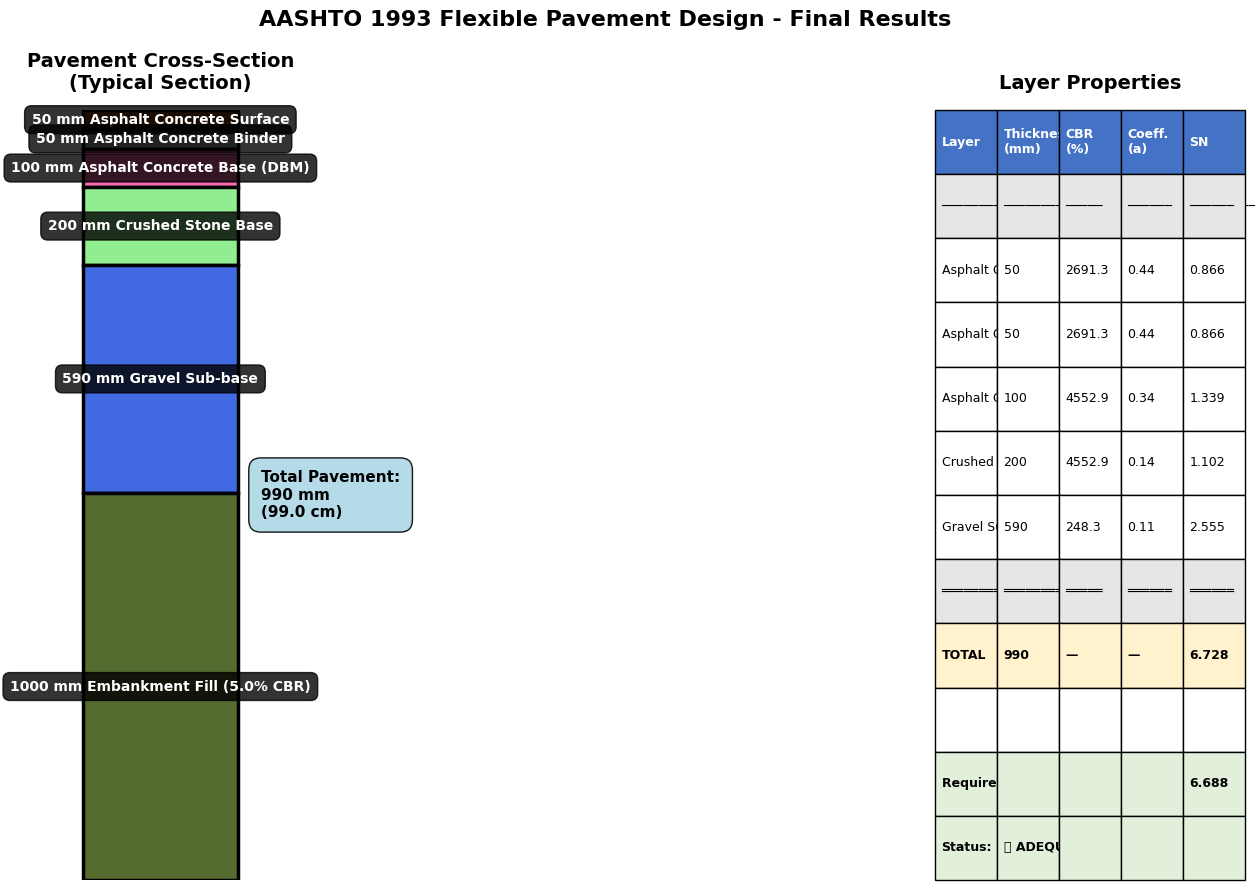


✅ Detailed pavement cross-section generated!


In [11]:
import matplotlib.patches as patches

print("\n" + "="*70)
print("  🎨 GENERATING DETAILED PAVEMENT CROSS-SECTION")
print("="*70)

# Prepare layer information
AC_surface_mm = 50
AC_binder_mm = D1_mm - AC_surface_mm

# Create figure with two subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 2], wspace=2)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Define colors for each layer
layer_colors = {
    'AC Surface': '#8B4513',
    'AC Binder': '#A9A9A9',
    'DBM Course': '#FF69B4',
    'Base Course': '#90EE90',
    'Subbase': '#4169E1',
    'Capping Layer': '#FF8C00',
    'Subgrade': '#556B2F'
}

# Build layer data
layers_info = []

# AC Surface
layers_info.append({
    'name': 'Asphalt Concrete Surface',
    'thickness_mm': AC_surface_mm,
    'color': layer_colors['AC Surface'],
    'cbr': cbr_surface,
    'coefficient': a1,
    'sn': (AC_surface_mm / 25.4) * a1
})

# AC Binder
if AC_binder_mm > 0:
    layers_info.append({
        'name': 'Asphalt Concrete Binder',
        'thickness_mm': AC_binder_mm,
        'color': layer_colors['AC Binder'],
        'cbr': cbr_surface,
        'coefficient': a1,
        'sn': (AC_binder_mm / 25.4) * a1
    })

# DBM Course
layers_info.append({
    'name': 'Asphalt Concrete Base (DBM)',
    'thickness_mm': D2_mm,
    'color': layer_colors['DBM Course'],
    'cbr': cbr_base,
    'coefficient': a2,
    'sn': SN2_actual
})

# Base Course
layers_info.append({
    'name': 'Crushed Stone Base',
    'thickness_mm': D3_mm,
    'color': layer_colors['Base Course'],
    'cbr': cbr_base,
    'coefficient': a3,
    'sn': SN3_actual
})

# Subbase
layers_info.append({
    'name': 'Gravel Sub-base',
    'thickness_mm': D4_mm,
    'color': layer_colors['Subbase'],
    'cbr': cbr_subbase,
    'coefficient': a4,
    'sn': SN4_actual
})

# Capping Layer
if use_capping_layer:
    layers_info.append({
        'name': 'Capping Layer',
        'thickness_mm': D5_mm,
        'color': layer_colors['Capping Layer'],
        'cbr': cbr_capping,
        'coefficient': a5,
        'sn': SN5_actual
    })

# Subgrade
layers_info.append({
    'name': f'Embankment Fill ({cbr_subgrade}% CBR)',
    'thickness_mm': 1000,  # Display height
    'color': layer_colors['Subgrade'],
    'cbr': cbr_subgrade,
    'coefficient': 0,
    'sn': 0
})
scale_factor = 0.025 # Increase this value for thicker visual layers

# PLOT 1: Cross-section diagram
y_position = 0
for layer in layers_info:
    height = layer['thickness_mm']

    # Draw rectangle
    rect = patches.Rectangle((0, y_position), 10, height*scale_factor,
                             linewidth=2.5, edgecolor='black',
                             facecolor=layer['color'])
    ax1.add_patch(rect)

    # Add layer name
    text_y = y_position + height*scale_factor / 2
    ax1.text(5, text_y, f"{layer['thickness_mm']:.0f} mm {layer['name']}",
           ha='center', va='center', fontsize=10, fontweight='bold',
           color='white', bbox=dict(boxstyle='round,pad=0.5',
                                   facecolor='black', alpha=0.8))

    y_position += height*scale_factor

# Set properties for cross-section
ax1.set_xlim(-1, 11)
ax1.set_ylim(0, y_position)
ax1.invert_yaxis()   # 🔹 Invert vertically so top layer appears on top
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Pavement Cross-Section\n(Typical Section)',
             fontsize=14, fontweight='bold', pad=15)

# Add total thickness annotation
total_without_subgrade = sum([l['thickness_mm'] for l in layers_info[:-1]])
ax1.text(11.5, y_position/2,
       f'Total Pavement:\n{total_without_subgrade:.0f} mm\n({total_without_subgrade/10:.1f} cm)',
       fontsize=11, fontweight='bold', va='center',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.9))

# PLOT 2: Layer details table
ax2.axis('off')
ax2.set_title('Layer Properties', fontsize=14, fontweight='bold', pad=15)

# Create table data
table_data = []
table_data.append(['Layer', 'Thickness\n(mm)', 'CBR\n(%)', 'Coeff.\n(a)', 'SN'])
table_data.append(['─'*50, '─'*8, '─'*5, '─'*6, '─'*6])

for layer in layers_info[:-1]:  # Exclude subgrade
    table_data.append([
        layer['name'][:20],
        f"{layer['thickness_mm']:.0f}",
        f"{layer['cbr']:.1f}",
        f"{layer['coefficient']:.2f}",
        f"{layer['sn']:.3f}"
    ])

# Add summary
table_data.append(['═'*20, '═'*8, '═'*5, '═'*6, '═'*6])
table_data.append([
    'TOTAL',
    f"{total_without_subgrade:.0f}",
    '—',
    '—',
    f"{cumulative_SN:.3f}"
])
table_data.append(['', '', '', '', ''])
table_data.append([
    'Required SN:',
    '',
    '',
    '',
    f"{SN_required:.3f}"
])
table_data.append([
    'Status:',
    '✅ ADEQUATE' if is_adequate else '❌ NOT ADEQUATE',
    '',
    '',
    ''
])

# Draw table
table = ax2.table(cellText=table_data, cellLoc='left', loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Style the table
for i, row in enumerate(table_data):
    for j in range(len(row)):
        cell = table[(i, j)]
        if i == 0:  # Header
            cell.set_facecolor('#4472C4')
            cell.set_text_props(weight='bold', color='white')
        elif i == 1:  # Separator
            cell.set_facecolor('#E7E6E6')
        elif '═' in str(row[0]):  # Total separator
            cell.set_facecolor('#E7E6E6')
        elif 'TOTAL' in str(row[0]):  # Total row
            cell.set_facecolor('#FFF2CC')
            cell.set_text_props(weight='bold')
        elif 'Required' in str(row[0]) or 'Status' in str(row[0]):
            cell.set_facecolor('#E2EFDA')
            cell.set_text_props(weight='bold')

plt.suptitle('AASHTO 1993 Flexible Pavement Design - Final Results',
            fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("\n✅ Detailed pavement cross-section generated!")
print("="*70)